In [3]:
from math import comb

def prob_al_menos_2(n, p):
    """
    Calcula la probabilidad de que al menos 2 inversores
    estén a favor, dado n inversores y probabilidad p.
    
    n: número de inversores
    p: probabilidad de que un inversor esté a favor
    """
    # Probabilidad de 0 a favor
    p0 = comb(n, 0) * (p**0) * ((1-p)**n)
    # Probabilidad de 1 a favor
    p1 = comb(n, 1) * (p**1) * ((1-p)**(n-1))
    
    return 1 - (p0 + p1)

# Ejemplo: 5 inversores, probabilidad 0.6 de estar a favor
n = 3
p = 0.6
resultado = prob_al_menos_2(n, p)
print(f"Probabilidad de al menos 2 a favor: {resultado:.4f}")


print(comb(3,2)*(0.4*0.4)*0.6**1)

print(comb(3,2))

Probabilidad de al menos 2 a favor: 0.6480
0.28800000000000003
3


In [4]:
print((0.432*0.3)+(0.288*0.7))

0.33119999999999994


In [5]:
0.1296/0.3312

0.3913043478260869

Procesos estocasticos (O-U)


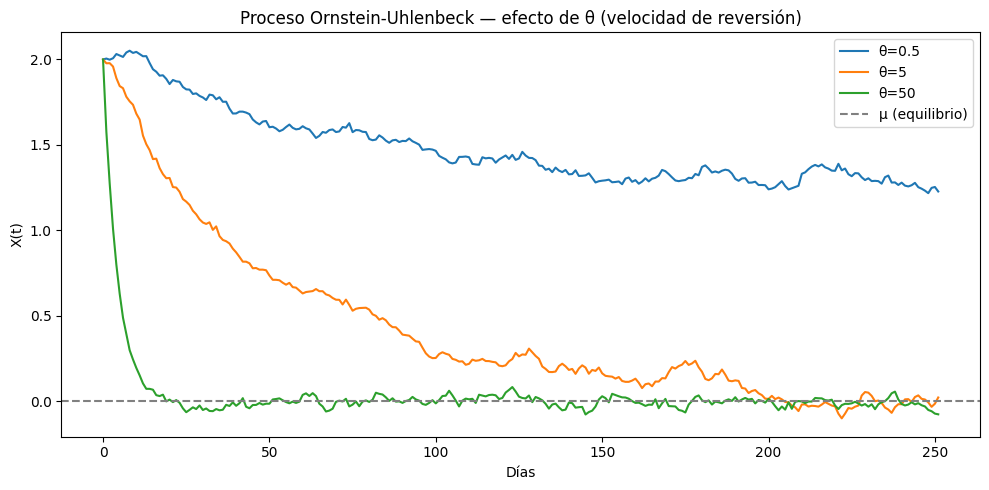

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
T = 252
dt = 1/252
mu = 0       # nivel de equilibrio
sigma = 0.3  # volatilidad del ruido

fig, ax = plt.subplots(figsize=(10, 5))

for theta in [0.5, 5, 50]:
    X = np.zeros(T)
    X[0] = 2  # empieza lejos del equilibrio
    
    for t in range(1, T):
        dW = np.random.normal(0, np.sqrt(dt))
        X[t] = X[t-1] + theta*(mu - X[t-1])*dt + sigma*dW
    
    ax.plot(X, label=f"θ={theta}")

ax.axhline(mu, color='gray', linestyle='--', label="μ (equilibrio)")
ax.set_title("Proceso Ornstein-Uhlenbeck — efecto de θ (velocidad de reversión)")
ax.set_xlabel("Días")
ax.set_ylabel("X(t)")
ax.legend()
plt.tight_layout()
plt.show()

Estimacion de theta de un spread real con regresion simple

[*********************100%***********************]  2 of 2 completed


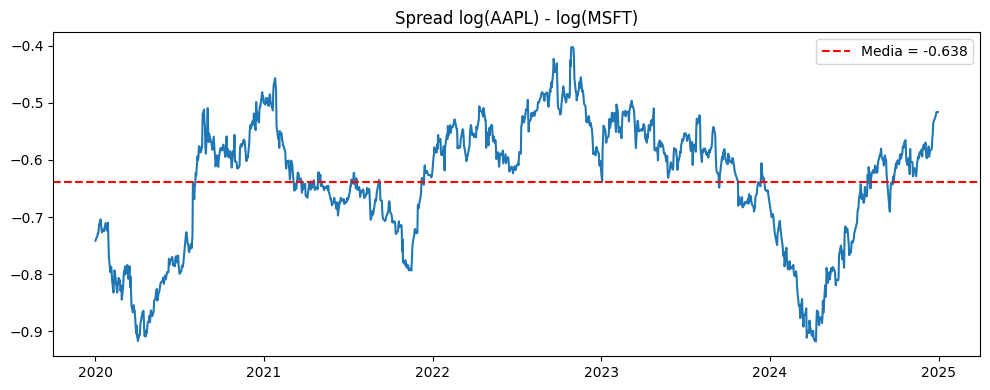

Coeficiente b: -0.00800
Theta estimado (velocidad de reversión): 2.017
Mu (nivel de equilibrio del spread): -0.6157

Vida media de reversión (días): 0.3

p-value de b: 0.02626
¿Reversión estadísticamente significativa? Sí


In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

data = yf.download(["AAPL", "MSFT"], start="2020-01-01", end="2024-12-31")["Close"]

spread = np.log(data["AAPL"]) - np.log(data["MSFT"])
spread = spread.dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(spread)
ax.axhline(spread.mean(), color='red', linestyle='--', label=f"Media = {spread.mean():.3f}")
ax.set_title("Spread log(AAPL) - log(MSFT)")
ax.legend()
plt.tight_layout()
plt.show()

# --- Estimar theta vía regresión discreta de Ornstein-Uhlenbeck ---
X_t = spread.shift(1).dropna()
delta_X = spread.diff().dropna()

X_t, delta_X = X_t.align(delta_X, join='inner')

# Renombrar explícitamente para evitar el KeyError de .name perdido
X_t = X_t.rename("X_t")
delta_X = delta_X.rename("delta_X")

X_reg = sm.add_constant(X_t)
modelo_ou = sm.OLS(delta_X, X_reg).fit()

a = modelo_ou.params["const"]
b = modelo_ou.params["X_t"]   # ahora el nombre es fijo, no depende de .name

dt = 1/252
theta = -b / dt
mu_equilibrio = -a / b

print(f"Coeficiente b: {b:.5f}")
print(f"Theta estimado (velocidad de reversión): {theta:.3f}")
print(f"Mu (nivel de equilibrio del spread): {mu_equilibrio:.4f}")
print(f"\nVida media de reversión (días): {np.log(2)/theta:.1f}")
print(f"\np-value de b: {modelo_ou.pvalues['X_t']:.5f}")
print(f"¿Reversión estadísticamente significativa? "
      f"{'Sí' if modelo_ou.pvalues['X_t'] < 0.05 else 'No'}")

In [4]:
print(f"theta calculado: {theta}")
print(f"ln(2)/theta = {np.log(2)/theta}")

theta calculado: 2.016824833112444
ln(2)/theta = 0.34368239084514496


Montecarlo y Kelly Criterion Project

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

p = 0.6       # probabilidad de ganar (edge asumido)
b = 1         # payout: ganas 1x lo apostado si ganas
kelly_optimo = p - (1-p)/b
print(f"Kelly óptimo teórico: f* = {kelly_optimo:.3f}")

Kelly óptimo teórico: f* = 0.200


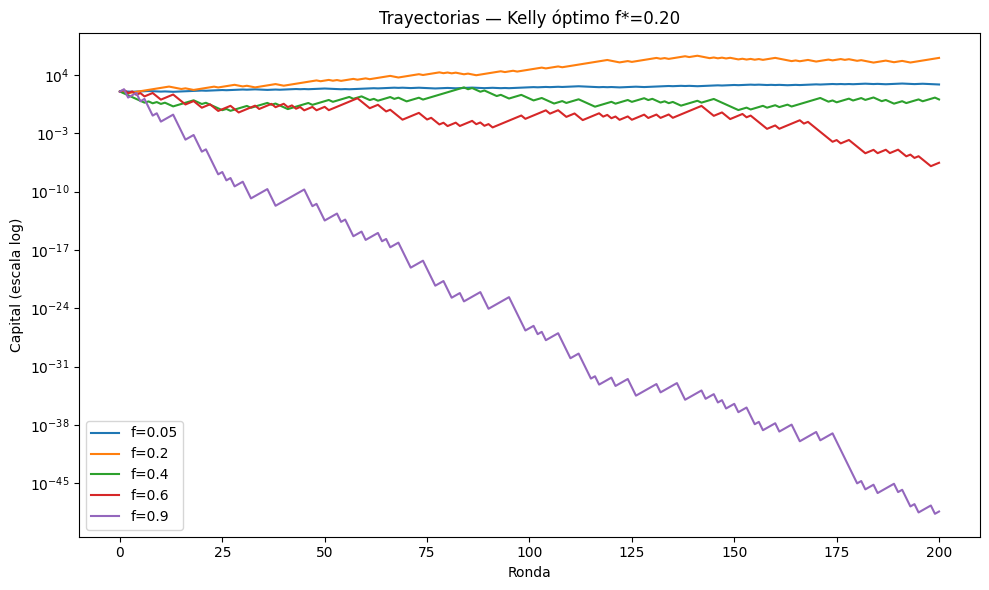

In [2]:
n_rondas = 200
n_simulaciones = 1000
capital_inicial = 100
fracciones = [0.05, 0.20, 0.40, 0.60, 0.90]

resultados_finales = {}
fig, ax = plt.subplots(figsize=(10, 6))

for f in fracciones:
    capitales_finales = []
    trayectoria_ejemplo = [capital_inicial]
    capital = capital_inicial
    
    for ronda in range(n_rondas):
        gana = np.random.random() < p
        capital = capital * (1 + f*b) if gana else capital * (1 - f)
        trayectoria_ejemplo.append(capital)
    
    ax.plot(trayectoria_ejemplo, label=f"f={f}")
    
    for _ in range(n_simulaciones):
        capital_sim = capital_inicial
        for ronda in range(n_rondas):
            gana = np.random.random() < p
            capital_sim = capital_sim * (1 + f*b) if gana else capital_sim * (1 - f)
        capitales_finales.append(capital_sim)
    
    resultados_finales[f] = capitales_finales

ax.set_yscale('log')
ax.set_title(f"Trayectorias — Kelly óptimo f*={kelly_optimo:.2f}")
ax.set_xlabel("Ronda")
ax.set_ylabel("Capital (escala log)")
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
print(f"{'f':>6} | {'Mediana':>15} | {'Percentil 5%':>15} | {'Percentil 95%':>18}")
print("-" * 62)
for f in fracciones:
    capitales = np.array(resultados_finales[f])
    print(f"{f:>6.2f} | ${np.median(capitales):>14,.2f} | "
          f"${np.percentile(capitales,5):>14,.2f} | "
          f"${np.percentile(capitales,95):>17,.2f}")

     f |         Mediana |    Percentil 5% |      Percentil 95%
--------------------------------------------------------------
  0.05 | $        576.24 | $        173.39 | $         1,732.71
  0.20 | $      5,609.81 | $         43.24 | $       727,852.86
  0.40 | $         61.30 | $          0.01 | $       684,240.77
  0.60 | $          0.00 | $          0.00 | $            19.14
  0.90 | $          0.00 | $          0.00 | $             0.00


In [4]:
print("Kelly completo (f=0.20) vs Kelly fraccionario/conservador (f=0.05):\n")
for f in [0.05, 0.20]:
    capitales = np.array(resultados_finales[f])
    prob_bajo_inicial = np.mean(capitales < capital_inicial)
    print(f"f={f}:")
    print(f"  Mediana:                    ${np.median(capitales):,.2f}")
    print(f"  Peor 5% de casos:           ${np.percentile(capitales,5):,.2f}")
    print(f"  P(terminar por debajo de $100 inicial): {prob_bajo_inicial*100:.1f}%")
    print()

Kelly completo (f=0.20) vs Kelly fraccionario/conservador (f=0.05):

f=0.05:
  Mediana:                    $576.24
  Peor 5% de casos:           $173.39
  P(terminar por debajo de $100 inicial): 0.4%

f=0.2:
  Mediana:                    $5,609.81
  Peor 5% de casos:           $43.24
  P(terminar por debajo de $100 inicial): 10.1%



In [ ]:
p_falso_positivo = 0.05
n_pruebas = 50

p_ninguna_falsa = (1 - p_falso_positivo) ** n_pruebas
p_al_menos_una_falsa = 1 - p_ninguna_falsa

print(f"P(ninguna falsa alarma en 50 pruebas):     {p_ninguna_falsa*100:.1f}%")
print(f"P(al menos UNA falsa alarma en 50 pruebas): {p_al_menos_una_falsa*100:.1f}%")

[*********************100%***********************]  1 of 1 completed


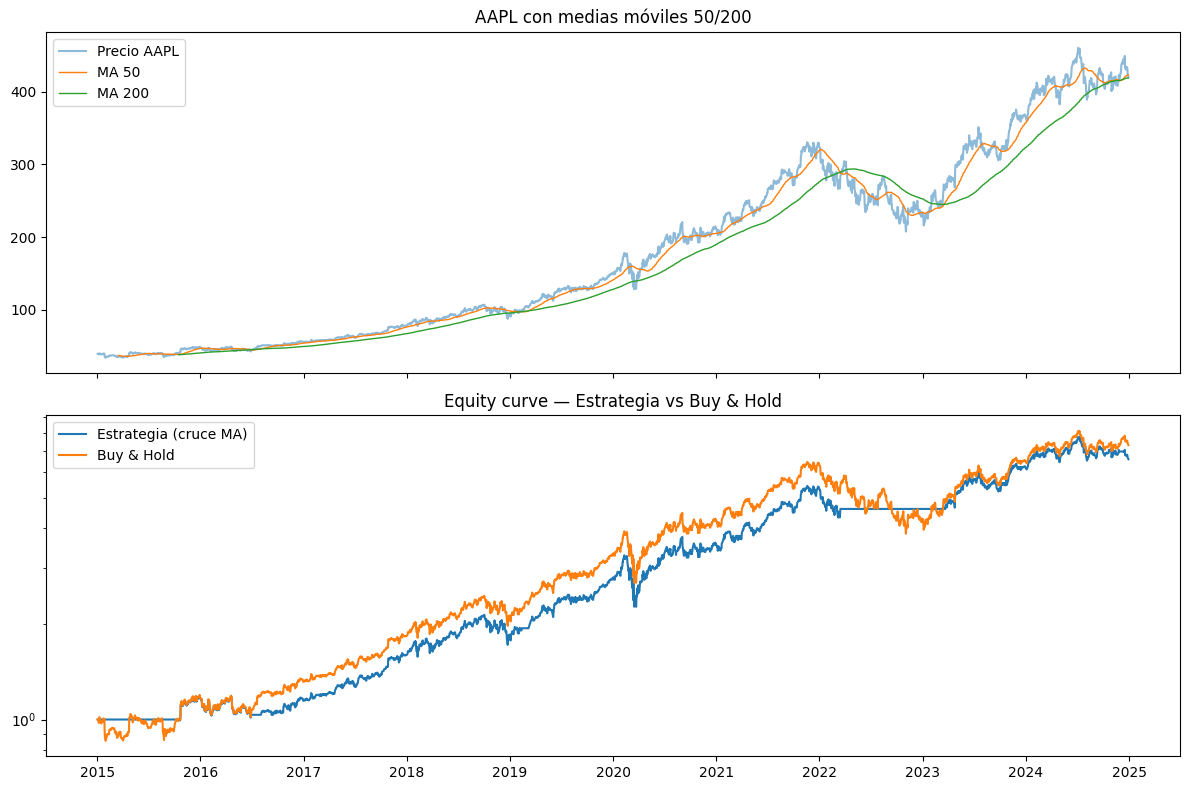

Estrategia — Retorno anualizado: 21.67%  Vol: 23.39%  Sharpe: 0.93
Buy&Hold  — Retorno anualizado: 23.65%  Vol: 27.13%  Sharpe: 0.87


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Descargamos un activo para probar la estrategia
data = yf.download("MSFT", start="2015-01-01", end="2024-12-31")["Close"]
if isinstance(data, pd.DataFrame):
    data = data.squeeze()

# --- Medias móviles desde primeros principios ---
ma_corta = data.rolling(window=50).mean()
ma_larga = data.rolling(window=200).mean()

# --- Señal: 1 = estar comprado (posición larga), 0 = fuera del mercado ---
# Cuando MA corta > MA larga → tendencia alcista → comprado
señal = (ma_corta > ma_larga).astype(int)

# --- IMPORTANTE: la señal de HOY se aplica al retorno de MAÑANA ---
# (no puedes operar con información que aún no tenías al cierre del día)
señal_shifted = señal.shift(1)

retornos_activo = np.log(data / data.shift(1))
retornos_estrategia = retornos_activo * señal_shifted

# --- Comparación: estrategia vs buy & hold ---
equity_estrategia = (1 + retornos_estrategia.fillna(0)).cumprod()
equity_buyhold = (1 + retornos_activo.fillna(0)).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(data, label="Precio AAPL", alpha=0.5)
axes[0].plot(ma_corta, label="MA 50", linewidth=1)
axes[0].plot(ma_larga, label="MA 200", linewidth=1)
axes[0].set_title("AAPL con medias móviles 50/200")
axes[0].legend()

axes[1].plot(equity_estrategia, label="Estrategia (cruce MA)")
axes[1].plot(equity_buyhold, label="Buy & Hold")
axes[1].set_title("Equity curve — Estrategia vs Buy & Hold")
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

# Métricas básicas
ret_anual_estrategia = retornos_estrategia.mean() * 252
ret_anual_bh = retornos_activo.mean() * 252
vol_estrategia = retornos_estrategia.std() * np.sqrt(252)
vol_bh = retornos_activo.std() * np.sqrt(252)

print(f"Estrategia — Retorno anualizado: {ret_anual_estrategia*100:.2f}%  "
      f"Vol: {vol_estrategia*100:.2f}%  Sharpe: {ret_anual_estrategia/vol_estrategia:.2f}")
print(f"Buy&Hold  — Retorno anualizado: {ret_anual_bh*100:.2f}%  "
      f"Vol: {vol_bh*100:.2f}%  Sharpe: {ret_anual_bh/vol_bh:.2f}")

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Mezcla de acciones y forex/oro
activos = {
    "AAPL":    "AAPL",
    "MSFT":    "MSFT",
    "EUR/USD": "EURUSD=X",
    "GBP/USD": "GBPUSD=X",
    "Oro":     "GC=F",
}

resultados = []

for nombre, ticker in activos.items():
    data = yf.download(ticker, start="2015-01-01", end="2024-12-31")["Close"]
    if isinstance(data, pd.DataFrame):
        data = data.squeeze()
    data = data.dropna()
    
    ma_corta = data.rolling(window=50).mean()
    ma_larga = data.rolling(window=200).mean()
    señal = (ma_corta > ma_larga).astype(int)
    señal_shifted = señal.shift(1)
    
    retornos_activo = np.log(data / data.shift(1))
    retornos_estrategia = retornos_activo * señal_shifted
    
    ret_anual_est = retornos_estrategia.mean() * 252
    vol_est = retornos_estrategia.std() * np.sqrt(252)
    sharpe_est = ret_anual_est / vol_est
    
    ret_anual_bh = retornos_activo.mean() * 252
    vol_bh = retornos_activo.std() * np.sqrt(252)
    sharpe_bh = ret_anual_bh / vol_bh
    
    resultados.append({
        "Activo": nombre,
        "Sharpe Estrategia": round(sharpe_est, 2),
        "Sharpe Buy&Hold": round(sharpe_bh, 2),
        "¿Gana estrategia?": "✅" if sharpe_est > sharpe_bh else "❌"
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

n_gana = (df_resultados["¿Gana estrategia?"] == "✅").sum()
print(f"\nLa estrategia superó a buy&hold en {n_gana} de {len(df_resultados)} activos")

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

 Activo  Sharpe Estrategia  Sharpe Buy&Hold ¿Gana estrategia?
   AAPL               0.69             0.82                 ❌
   MSFT               0.93             0.87                 ✅
EUR/USD              -0.18            -0.18                 ✅
GBP/USD              -0.07            -0.22                 ✅
    Oro               0.36             0.54                 ❌

La estrategia superó a buy&hold en 3 de 5 activos


In [7]:
data_eur = yf.download("EURUSD=X", start="2015-01-01", end="2024-12-31")["Close"]
if isinstance(data_eur, pd.DataFrame):
    data_eur = data_eur.squeeze()
data_eur = data_eur.dropna()

ma_corta = data_eur.rolling(window=50).mean()
ma_larga = data_eur.rolling(window=200).mean()
señal = (ma_corta > ma_larga).astype(int)

print(f"% del tiempo comprado (señal=1): {señal.mean()*100:.1f}%")
print(f"Número de cambios de señal (cruces): {(señal.diff() != 0).sum()}")

[*********************100%***********************]  1 of 1 completed

% del tiempo comprado (señal=1): 40.6%
Número de cambios de señal (cruces): 17


In [8]:
print(f"Sharpe Estrategia (más decimales): {sharpe_est:.5f}")
print(f"Sharpe Buy&Hold (más decimales):   {sharpe_bh:.5f}")

Sharpe Estrategia (más decimales): 0.35734
Sharpe Buy&Hold (más decimales):   0.53792
